# matplotlib - 2D and 3D plotting in Python

In [ ]:
# This line configures matplotlib to show figures embedded in the notebook,
# instead of opening a new window for each figure.
%matplotlib inline
# %matplotlib notebook

## Introduction

Matplotlib is an excellent 2D and 3D graphics library for generating scientific figures. Some of the many advantages of this library include:

* Easy to get started
* Support for LaTeX-formatted labels and texts
* Great control of every element in a figure, including figure size and DPI. 
* High-quality output in many formats, including PNG, PDF, SVG, EPS, and PGF.
* GUI for interactively exploring figures *and* support for headless generation of figure files (useful for batch jobs).

One of the key features of matplotlib that I would like to emphasize, and that I think makes matplotlib highly suitable for generating figures for scientific publications is that all aspects of the figure can be controlled *programmatically*. This is important for reproducibility and convenient when one needs to regenerate the figure with updated data or change its appearance. 

More information at the Matplotlib web page: http://matplotlib.org/

To get started using Matplotlib in a Python program, either include the symbols from the `pylab` module (the easy way):

In [ ]:
from pylab import *

or, better, import the `matplotlib.pyplot` module under the name `plt`:

In [ ]:
import matplotlib
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

## MATLAB-like API

The easiest way to get started with plotting using matplotlib is often to use the MATLAB-like API provided by matplotlib. 

It is designed to be compatible with MATLAB's plotting functions, so it is easy to get started with if you are familiar with MATLAB.

In [ ]:
from pylab import *

### Example

A simple figure with MATLAB-like plotting API:

In [ ]:
x = np.linspace(0, 5, 10)
y = x**2

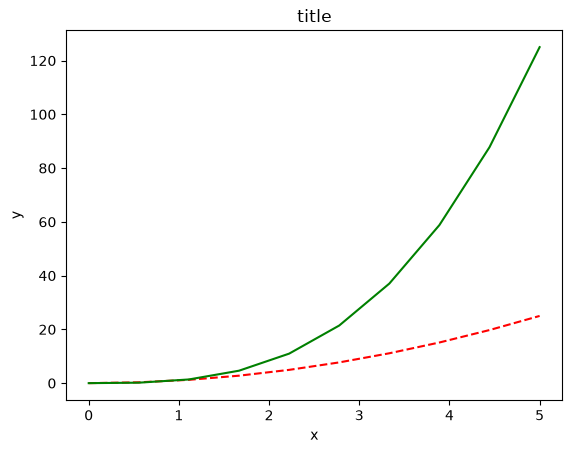

In [ ]:
figure()
plot(x, y, "r--")
plot(x, x**3, "g")
xlabel("x")
ylabel("y")
title("title")
# cla()
show()

Most of the plotting related functions in MATLAB are covered by the `pylab` module. For example, subplot and color/symbol selection:

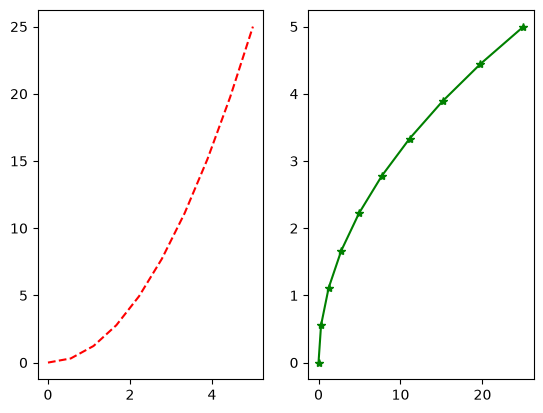

In [ ]:
subplot(1, 2, 1)
plot(x, y, "r--")
subplot(1, 2, 2)
plot(y, x, "g*-")

show()

The good thing about the pylab MATLAB-style API is that it is easy to get started with if you are familiar with MATLAB, and it has a minumum of coding overhead for simple plots. 

However, I'd encourage not using the MATLAB compatible API for anything but the simplest figures.

Instead, I recommend learning and using matplotlib's object-oriented plotting API. It is remarkably powerful. For advanced figures with subplots, insets and other components it is very nice to work with. 

## The matplotlib object-oriented API

The main idea with object-oriented programming is to have objects that one can apply functions and actions on, and no object or program states should be global (such as the MATLAB-like API). The real advantage of this approach becomes apparent when more than one figure is created, or when a figure contains more than one subplot. 

To use the object-oriented API we start out very much like in the previous example, but instead of creating a new global figure instance we store a reference to the newly created figure instance in the `fig` variable, and from it we create a new axis instance `axes` using the `add_axes` method in the `Figure` class instance `fig`:

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
x = np.linspace(0, 5, 10)
y = x**2

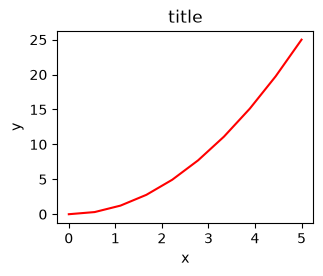

In [ ]:
# %matplotlib notebook
fig = plt.figure()

# axes = fig.add_axes([0.1, 0.1, 0.4, 0.4]) # left, bottom, width, height (range 0 to 1)
axes = fig.add_axes([0.1, 0.1, 0.4, 0.4])  # , frameon=False)
axes.plot(x, y, "r")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_title("title")
plt.show()

Although a little bit more code is involved, the advantage is that we now have full control of where the plot axes are placed, and we can easily add more than one axis to the figure:

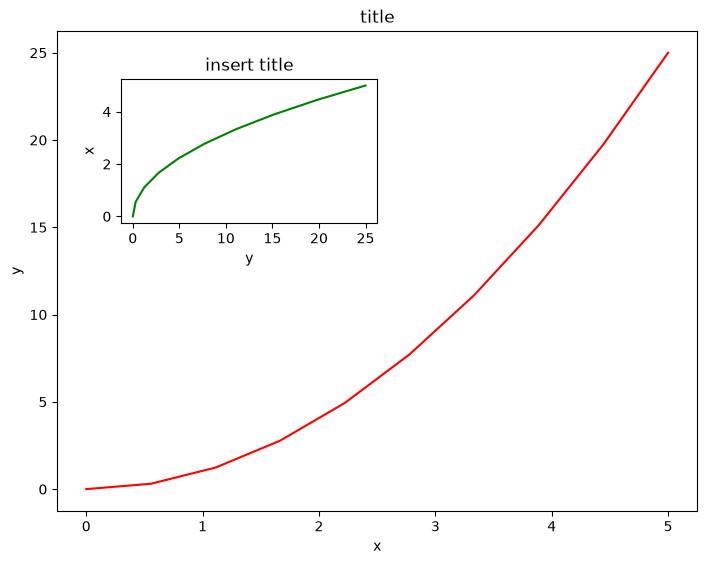

In [ ]:
%matplotlib inline
fig = plt.figure()

axes1 = fig.add_axes([0.1, 0.1, 1, 1])  # main axes
axes2 = fig.add_axes([0.2, 0.7, 0.4, 0.3])  # inset axes

# main figure
axes1.plot(x, y, "r")
axes1.set_xlabel("x")
axes1.set_ylabel("y")
axes1.set_title("title")

# insert
axes2.plot(y, x, "g")
axes2.set_xlabel("y")
axes2.set_ylabel("x")
axes2.set_title("insert title")
plt.show()

If we don't care about being explicit about where our plot axes are placed in the figure canvas, then we can use one of the many axis layout managers in matplotlib. My favorite is `subplots`, which can be used like this:

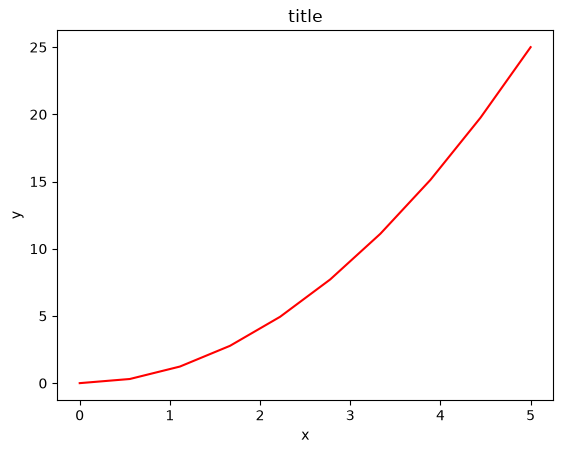

In [ ]:
fig, axes = plt.subplots()

axes.plot(x, y, "r")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_title("title")
plt.show()

[<Axes: > <Axes: >]
Axes(0.125,0.11;0.352273x0.77)
Axes(0.547727,0.11;0.352273x0.77)


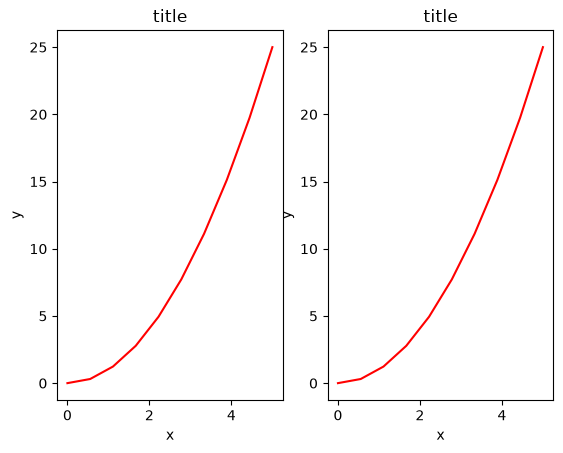

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2)
print(axes)

for ax in axes:
    print(ax)
    ax.plot(x, y, "r")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("title")
plt.show()

In [ ]:
print(axes)

[<Axes: title={'center': 'title'}, xlabel='x', ylabel='y'>
 <Axes: title={'center': 'title'}, xlabel='x', ylabel='y'>]


That was easy, but it isn't so pretty with overlapping figure axes and labels, right?

We can deal with that by using the `fig.tight_layout` method, which automatically adjusts the positions of the axes on the figure canvas so that there is no overlapping content:

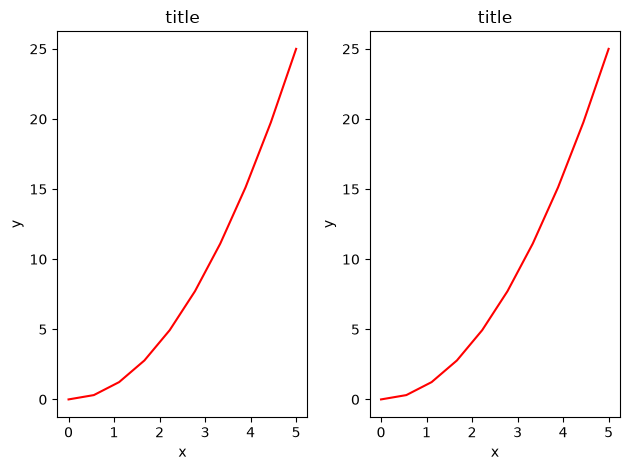

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2)

for ax in axes:
    ax.plot(x, y, "r")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("title")

fig.tight_layout()
plt.show()

### Figure size, aspect ratio and DPI

Matplotlib allows the aspect ratio, DPI and figure size to be specified when the `Figure` object is created, using the `figsize` and `dpi` keyword arguments. `figsize` is a tuple of the width and height of the figure in inches, and `dpi` is the dots-per-inch (pixel per inch). To create an 800x400 pixel, 100 dots-per-inch figure, we can do: 

In [ ]:
fig = plt.figure(figsize=(8, 4), dpi=100)

<Figure size 800x400 with 0 Axes>

The same arguments can also be passed to layout managers, such as the `subplots` function:

In [ ]:
help(plt.subplots)

Help on function subplots in module matplotlib.pyplot:

subplots(
    nrows: int = 1,
    ncols: int = 1,
    *,
    sharex: bool | Literal['none', 'all', 'row', 'col'] = False,
    sharey: bool | Literal['none', 'all', 'row', 'col'] = False,
    squeeze: bool = True,
    width_ratios: Sequence[float] | None = None,
    height_ratios: Sequence[float] | None = None,
    subplot_kw: dict[str, Any] | None = None,
    gridspec_kw: dict[str, Any] | None = None,
    **fig_kw: Any
) -> tuple[Figure, Any]
    Create a figure and a set of subplots.

    This utility wrapper makes it convenient to create common layouts of
    subplots, including the enclosing figure object, in a single call.

    Parameters
    ----------
    nrows, ncols : int, default: 1
        Number of rows/columns of the subplot grid.

    sharex, sharey : bool or {'none', 'all', 'row', 'col'}, default: False
        Controls sharing of properties among x (*sharex*) or y (*sharey*)
        axes:

        - True or 'all': x

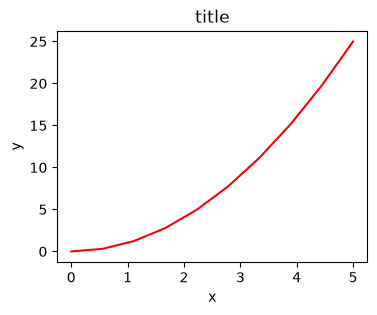

In [ ]:
fig, axes = plt.subplots(figsize=(4, 3))

axes.plot(x, y, "r")
axes.set_xlabel("x")
axes.set_ylabel("y")
axes.set_title("title")
plt.show()

### Saving figures

To save a figure to a file we can use the `savefig` method in the `Figure` class:

In [ ]:
fig.savefig("filename.png")

Here we can also optionally specify the DPI and choose between different output formats:

In [ ]:
fig.savefig("filename.png", dpi=200)

#### What formats are available and which ones should be used for best quality?

Matplotlib can generate high-quality output in a number formats, including PNG, JPG, EPS, SVG, PGF and PDF. For scientific papers, I recommend using PDF whenever possible. (LaTeX documents compiled with `pdflatex` can include PDFs using the `includegraphics` command). In some cases, PGF can also be a good alternative.

### Legends, labels and titles

Now that we have covered the basics of how to create a figure canvas and add axes instances to the canvas, let's look at how to decorate a figure with titles, axis labels, and legends.

**Figure titles**

A title can be added to each axis instance in a figure. To set the title, use the `set_title` method in the axes instance:

In [ ]:
ax.set_title("title")

Text(0.5, 1.0, 'title')

**Axis labels**

Similarly, with the methods `set_xlabel` and `set_ylabel`, we can set the labels of the X and Y axes:

In [ ]:
ax.set_xlabel("x")
ax.set_ylabel("y")

Text(336.38888888888886, 0.5, 'y')

**Legends**

Legends for curves in a figure can be added in two ways. One method is to use the `legend` method of the axis object and pass a list/tuple of legend texts for the previously defined curves:

In [ ]:
ax.legend(["curve1", "curve2", "curve3"])

The method described above follows the MATLAB API. It is somewhat prone to errors and inflexible if curves are added to or removed from the figure (resulting in a wrongly labelled curve).

A better method is to use the `label="label text"` keyword argument when plots or other objects are added to the figure, and then using the `legend` method without arguments to add the legend to the figure: 

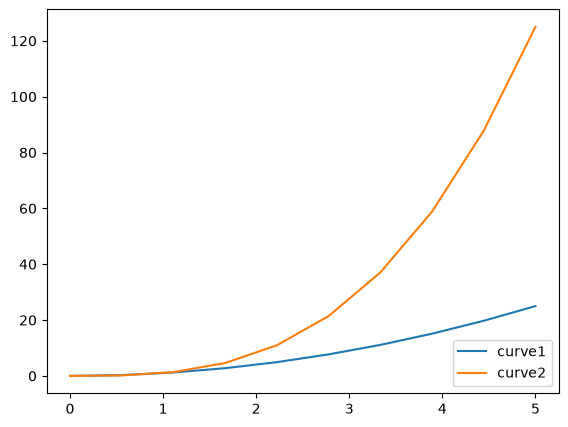

In [ ]:
fig = plt.figure()

ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])  # main axes

ax.plot(x, x**2, label="curve1")
ax.plot(x, x**3, label="curve2")
ax.legend(loc=4)
plt.show()

The advantage with this method is that if curves are added or removed from the figure, the legend is automatically updated accordingly.

The `legend` function takes an optional keyword argument `loc` that can be used to specify where in the figure the legend is to be drawn. The allowed values of `loc` are numerical codes for the various places the legend can be drawn. See http://matplotlib.org/users/legend_guide.html#legend-location for details. Some of the most common `loc` values are:

In [ ]:
ax.legend(loc=0)  # let matplotlib decide the optimal location
ax.legend(loc=1)  # upper right corner
ax.legend(loc=2)  # upper left corner
ax.legend(loc=3)  # lower left corner
ax.legend(loc=4)  # lower right corner
# .. many more options are available

The following figure shows how to use the figure title, axis labels and legends described above:

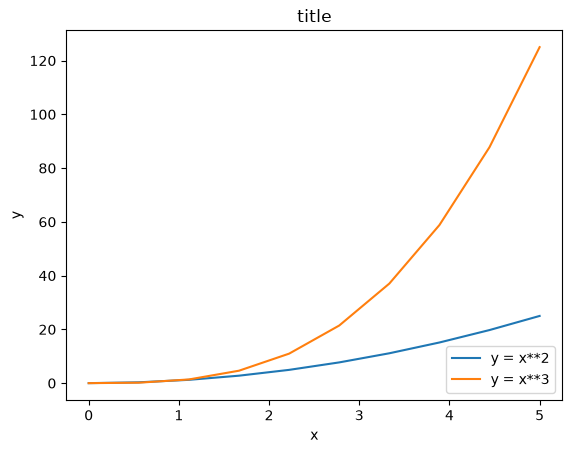

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label="y = x**2")
ax.plot(x, x**3, label="y = x**3")
ax.legend(loc=4)
# lower right corner
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("title")
plt.show()

### Formatting text: LaTeX, fontsize, font family

The figure above is functional, but it does not (yet) satisfy the criteria for a figure used in a publication. First and foremost, we need to have LaTeX formatted text, and second, we need to be able to adjust the font size to appear right in a publication.

Matplotlib has great support for LaTeX. All we need to do is to use dollar signs encapsulate LaTeX in any text (legend, title, label, etc.). For example, `"$y=x^3$"`.

But here we can run into a slightly subtle problem with LaTeX code and Python text strings. In LaTeX, we frequently use the backslash in commands, for example `\alpha` to produce the symbol $\alpha$. But the backslash already has a meaning in Python strings (the escape code character). To avoid Python messing up our latex code, we need to use "raw" text strings. Raw text strings are prepended with an '`r`', like `r"\alpha"` or `r'\alpha'` instead of `"\alpha"` or `'\alpha'`:

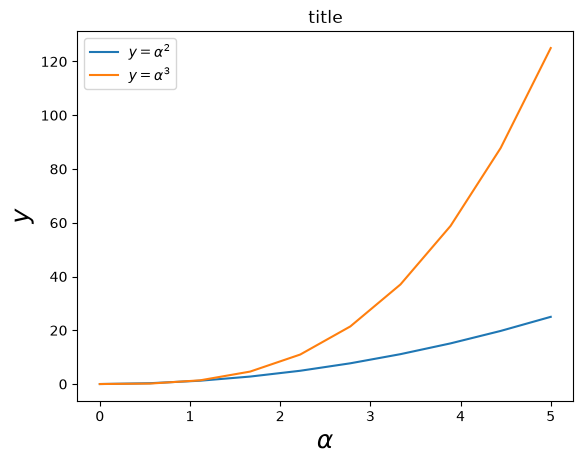

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2)  # upper left corner
ax.set_xlabel(r"$\alpha$", fontsize=18)
ax.set_ylabel(r"$y$", fontsize=18)
ax.set_title("title")
plt.show()

We can also change the global font size and font family, which applies to all text elements in a figure (tick labels, axis labels and titles, legends, etc.):

In [ ]:
# Update the matplotlib configuration parameters:
matplotlib.rcParams.update({"font.size": 18, "font.family": "serif"})

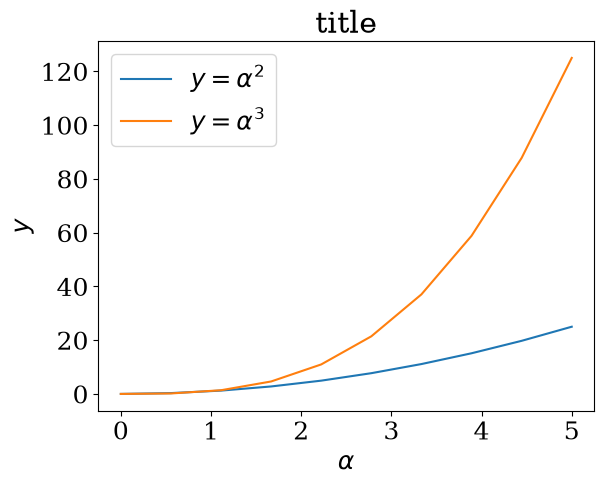

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2)  # upper left corner
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$y$")
ax.set_title("title")
plt.show()

A good choice of global fonts are the STIX fonts: 

In [ ]:
# Update the matplotlib configuration parameters:
matplotlib.rcParams.update(
    {"font.size": 18, "font.family": "STIXGeneral", "mathtext.fontset": "stix"}
)

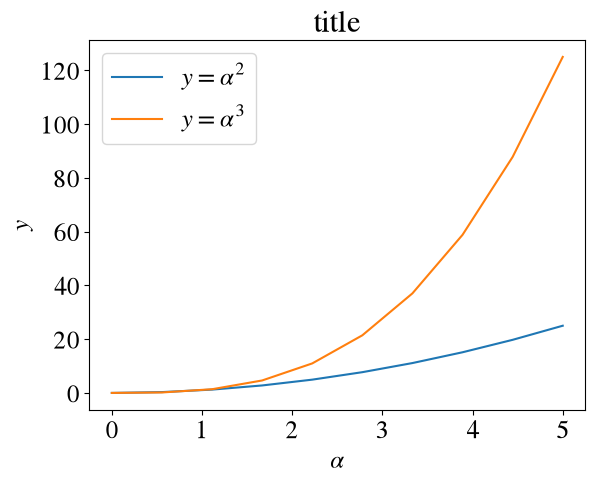

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2)  # upper left corner
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$y$")
ax.set_title("title")
plt.show()

Matplotlib can also use a system LaTeX installation to render text elements in a figure (via `text.usetex`). This gives the highest-quality typesetting, but requires LaTeX to be installed separately and is **not** enabled here, since it is not part of this course's environment. If you have a LaTeX installation available, you can try it yourself by uncommenting the line in the next cell:

In [ ]:
# requires a system LaTeX installation, not provided by this course's environment
# matplotlib.rcParams.update({"font.size": 18, "text.usetex": True})

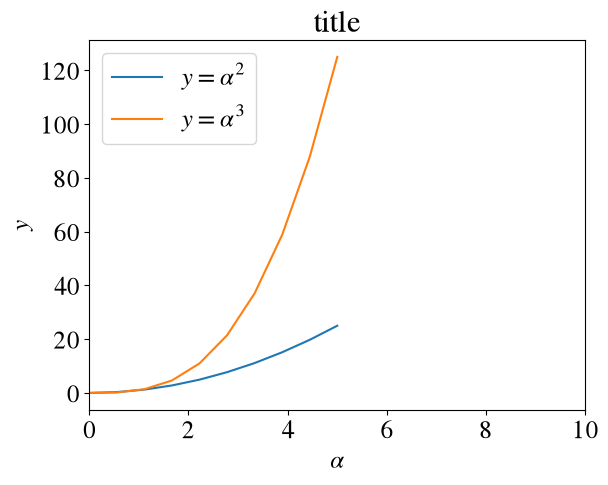

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x**2, label=r"$y = \alpha^2$")
ax.plot(x, x**3, label=r"$y = \alpha^3$")
ax.legend(loc=2)  # upper left corner
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$y$")
ax.set_title("title")
ax.set_xlim(0, 10)
plt.show()

In [ ]:
# restore
matplotlib.rcParams.update(
    {"font.size": 12, "font.family": "sans", "text.usetex": False}
)

### Setting colors, linewidths, linetypes

#### Colors

With matplotlib, we can define the colors of lines and other graphical elements in a number of ways. First of all, we can use the MATLAB-like syntax where `'b'` means blue, `'g'` means green, etc. The MATLAB API for selecting line styles are also supported: where, for example, 'b.-' means a blue line with dots:

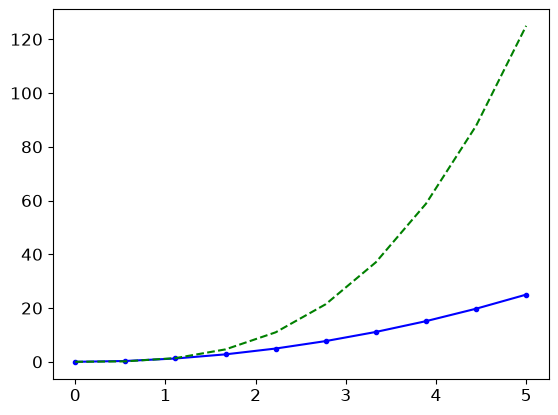

In [ ]:
fig, ax = plt.subplots()
# MATLAB style line color and style
ax.plot(x, x**2, "b.-")  # blue line with dots
ax.plot(x, x**3, "g--")  # green dashed line
plt.show()

We can also define colors by their names or RGB hex codes and optionally provide an alpha value using the `color` and `alpha` keyword arguments:

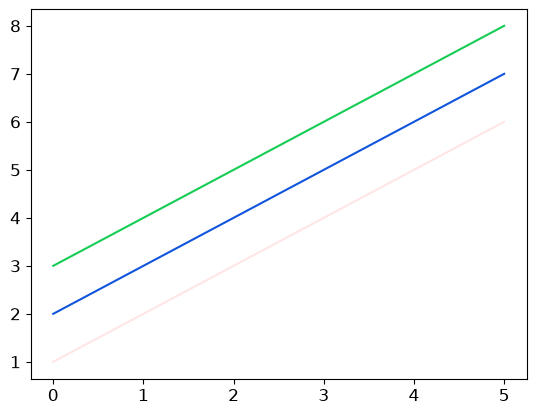

In [ ]:
fig, ax = plt.subplots()

ax.plot(x, x + 1, color="red", alpha=0.1)  # half-transparant red
ax.plot(x, x + 2, color="#1155dd")  # RGB hex code for a bluish color
ax.plot(x, x + 3, color="#15cc55")  # RGB hex code for a greenish color
plt.show()

#### Line and marker styles

To change the line width, we can use the `linewidth` or `lw` keyword argument. The line style can be selected using the `linestyle` or `ls` keyword arguments:

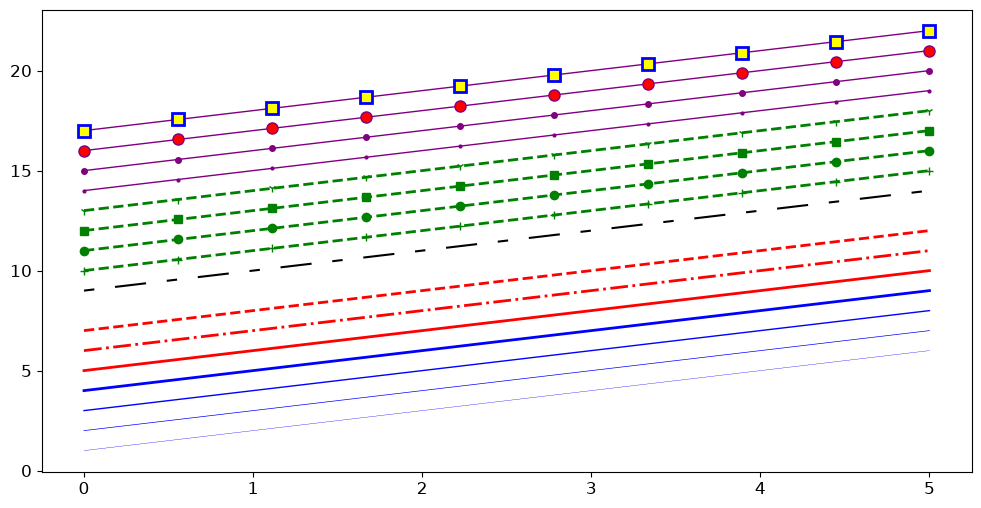

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x, x + 1, color="blue", linewidth=0.25)
ax.plot(x, x + 2, color="blue", linewidth=0.50)
ax.plot(x, x + 3, color="blue", linewidth=1.00)
ax.plot(x, x + 4, color="blue", linewidth=2.00)

# possible linestype options ‘-‘, ‘--’, ‘-.’, ‘:’,
# see https://matplotlib.org/api/_as_gen/matplotlib.lines.Line2D.html#matplotlib.lines.Line2D.set_linestyle
ax.plot(x, x + 5, color="red", lw=2, linestyle="-")
ax.plot(x, x + 6, color="red", lw=2, ls="-.")
line7 = ax.plot(x, x + 7, color="red", lw=2)
line7[0].set_linestyle("dashed")

# custom dash
line = ax.plot(x, x + 9, color="black", lw=1.50)
line[0].set_dashes([5, 10, 15, 10])  # format: line length, space length, ...

# possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(x, x + 10, color="green", lw=2, ls="--", marker="+")
ax.plot(x, x + 11, color="green", lw=2, ls="--", marker="o")
ax.plot(x, x + 12, color="green", lw=2, ls="--", marker="s")
ax.plot(x, x + 13, color="green", lw=2, ls="--", marker="1")

# marker size and color
ax.plot(x, x + 14, color="purple", lw=1, ls="-", marker="o", markersize=2)
ax.plot(x, x + 15, color="purple", lw=1, ls="-", marker="o", markersize=4)
ax.plot(
    x,
    x + 16,
    color="purple",
    lw=1,
    ls="-",
    marker="o",
    markersize=8,
    markerfacecolor="red",
)
ax.plot(
    x,
    x + 17,
    color="purple",
    lw=1,
    ls="-",
    marker="s",
    markersize=8,
    markerfacecolor="yellow",
    markeredgewidth=2,
    markeredgecolor="blue",
)
plt.show()

### Control over axis appearance

The appearance of the axes is an important aspect of a figure that we often need to modify to make a publication quality graphics. We need to be able to control where the ticks and labels are placed, modify the font size and possibly the labels used on the axes. In this section we will look at controlling those properties in a matplotlib figure.

#### Plot range

The first thing we might want to configure is the ranges of the axes. We can do this using the `set_ylim` and `set_xlim` methods in the axis object, or `axis('tight')` for automatically getting "tightly fitted" axes ranges:

[0.         0.55555556 1.11111111 1.66666667 2.22222222 2.77777778
 3.33333333 3.88888889 4.44444444 5.        ]


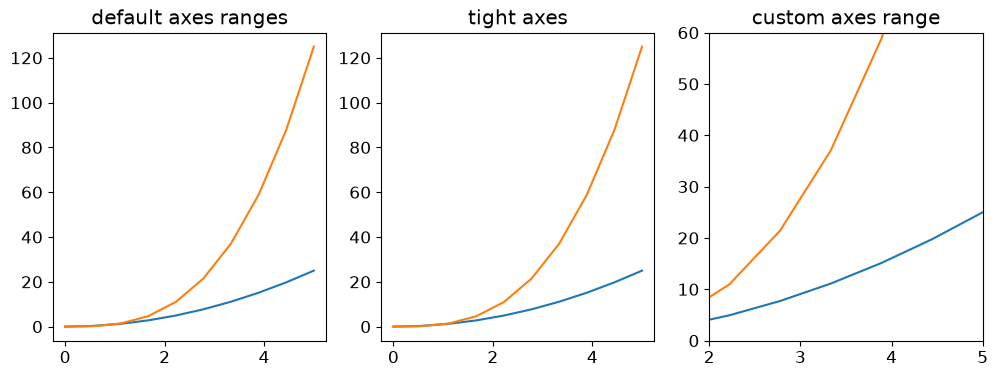

In [ ]:
print(x)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(x, x**2, x, x**3)
axes[0].set_title("default axes ranges")

axes[1].plot(x, x**2, x, x**3)
axes[1].axis("tight")
axes[1].set_title("tight axes")

axes[2].plot(x, x**2, x, x**3)
axes[2].set_ylim([0, 60])
axes[2].set_xlim([2, 5])
axes[2].set_title("custom axes range")
plt.show()

#### Logarithmic scale

It is also possible to set a logarithmic scale for one or both axes. This functionality is in fact only one application of a more general transformation system in Matplotlib. Each of the axes' scales are set separately using `set_xscale` and `set_yscale` methods which accept one parameter (with the value "log" in this case):

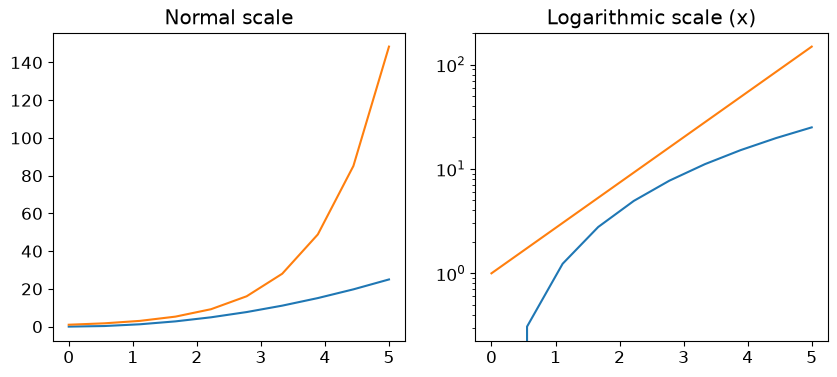

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(x, x**2, x, np.exp(x))
axes[0].set_title("Normal scale")

axes[1].plot(x, x**2, x, np.exp(x))
# axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Logarithmic scale (x)")
plt.show()

### Placement of ticks and custom tick labels

We can explicitly determine where we want the axis ticks with `set_xticks` and `set_yticks`, which both take a list of values for where on the axis the ticks are to be placed. We can also use the `set_xticklabels` and `set_yticklabels` methods to provide a list of custom text labels for each tick location:

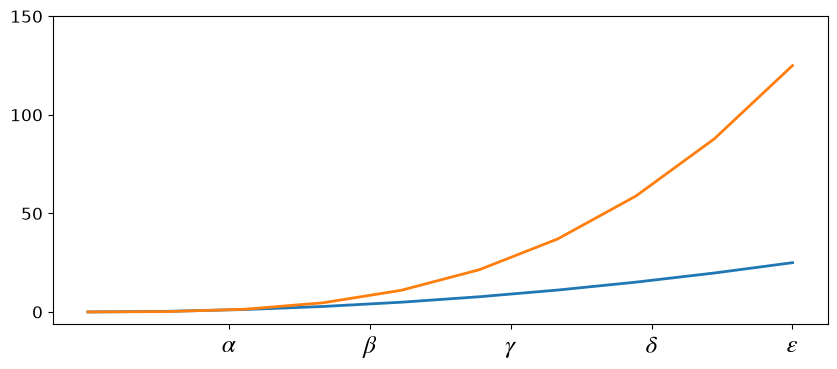

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(x, x**2, x, x**3, lw=2)

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(
    [r"$\alpha$", r"$\beta$", r"$\gamma$", r"$\delta$", r"$\epsilon$"], fontsize=18
)

yticks = [0, 50, 100, 150]
ax.set_yticks(yticks)
# ax.set_yticklabels(["$%.1f$" % y for y in yticks], fontsize=18); # use LaTeX formatted labels
plt.show()

There are a number of more advanced methods for controlling major and minor tick placement in matplotlib figures, such as automatic placement according to different policies. See http://matplotlib.org/api/ticker_api.html for details.

#### Scientific notation

With large numbers on axes, it is often better use scientific notation:

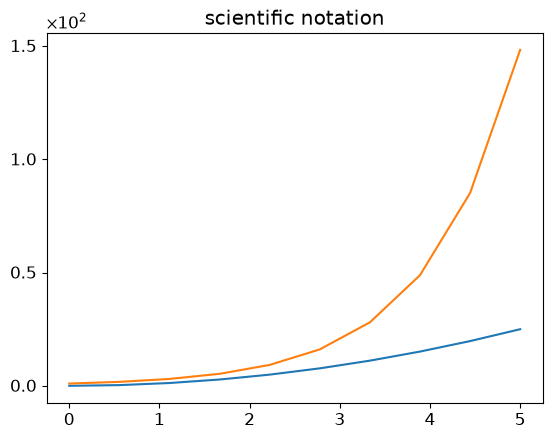

In [ ]:
fig, ax = plt.subplots(1, 1)

ax.plot(x, x**2, x, np.exp(x))
ax.set_title("scientific notation")

ax.set_yticks([0, 50, 100, 150])

from matplotlib import ticker

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
ax.yaxis.set_major_formatter(formatter)
plt.show()

### Axis number and axis label spacing

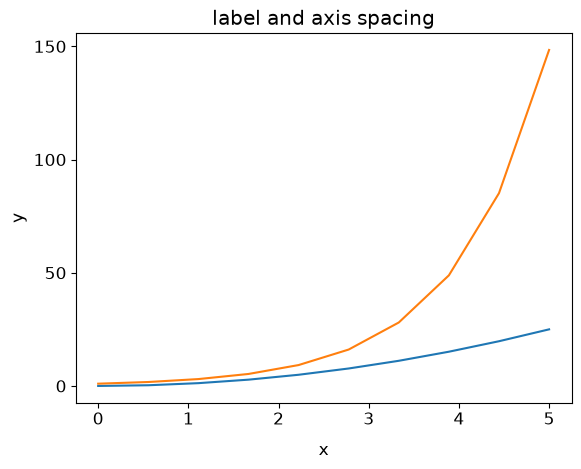

In [ ]:
# distance between x and y axis and the numbers on the axes
matplotlib.rcParams["xtick.major.pad"] = 3
matplotlib.rcParams["ytick.major.pad"] = 3

fig, ax = plt.subplots(1, 1)

ax.plot(x, x**2, x, np.exp(x))
ax.set_yticks([0, 50, 100, 150])

ax.set_title("label and axis spacing")

# padding between axis label and axis numbers
ax.xaxis.labelpad = 10
ax.yaxis.labelpad = 5

ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

In [ ]:
# restore defaults
matplotlib.rcParams["xtick.major.pad"] = 3
matplotlib.rcParams["ytick.major.pad"] = 3

#### Axis position adjustments

Unfortunately, when saving figures the labels are sometimes clipped, and it can be necessary to adjust the positions of axes a little bit. This can be done using `subplots_adjust`:

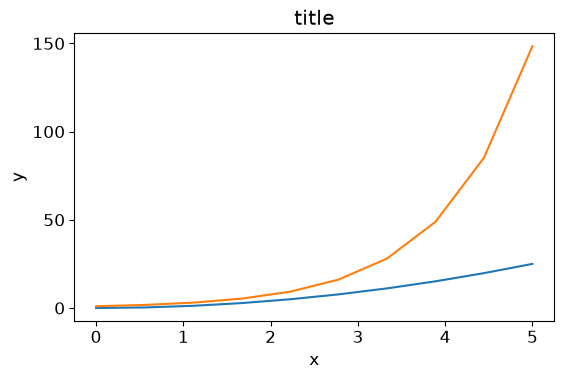

In [ ]:
fig, ax = plt.subplots(1, 1)

ax.plot(x, x**2)
ax.plot(x, np.exp(x))
ax.set_yticks([0, 50, 100, 150])

ax.set_title("title")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.subplots_adjust(left=0.15, right=0.9, bottom=0.3, top=0.9)

fig.savefig("fig1.eps")
plt.show()

### Axis grid

With the `grid` method in the axis object, we can turn on and off grid lines. We can also customize the appearance of the grid lines using the same keyword arguments as the `plot` function:

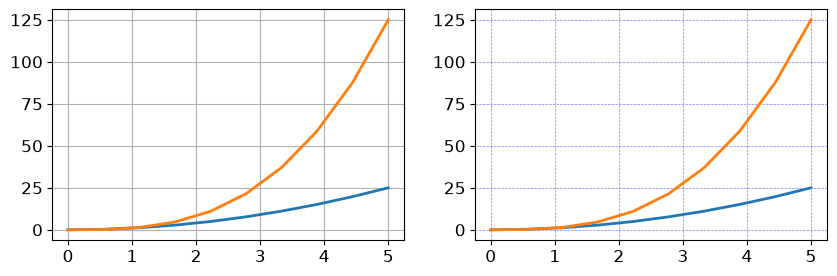

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# default grid appearance
axes[0].plot(x, x**2, x, x**3, lw=2)
axes[0].grid(True)

# custom grid appearance
axes[1].plot(x, x**2, x, x**3, lw=2)
axes[1].grid(color="b", alpha=0.5, linestyle="dashed", linewidth=0.5)
plt.show()

### Axis spines

We can also change the properties of axis spines:

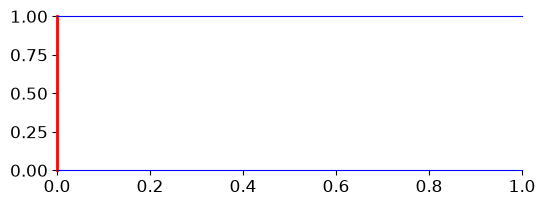

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2))

ax.spines["bottom"].set_color("blue")
ax.spines["top"].set_color("blue")

ax.spines["left"].set_color("red")
ax.spines["left"].set_linewidth(2)

# turn off axis spine to the right
ax.spines["right"].set_color("none")
ax.yaxis.tick_left()  # only ticks on the left side
plt.show()

### Twin axes

Sometimes it is useful to have dual x or y axes in a figure; for example, when plotting curves with different units together. Matplotlib supports this with the `twinx` and `twiny` functions:

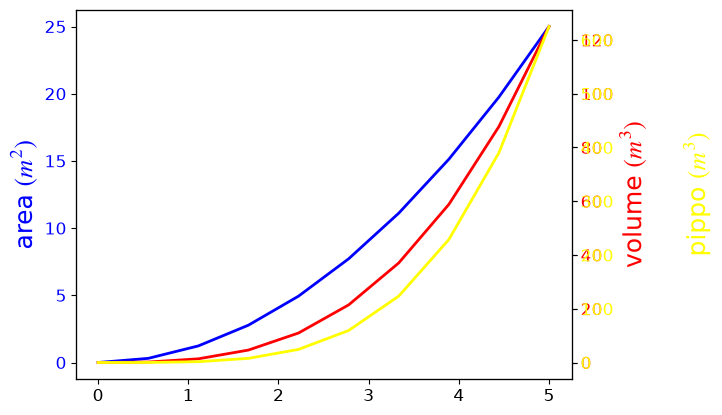

In [ ]:
fig, ax1 = plt.subplots()

ax1.plot(x, x**2, lw=2, color="blue")
ax1.set_ylabel("area $(m^2)$", fontsize=18, color="blue")
for label in ax1.get_yticklabels():
    label.set_color("blue")

ax2 = ax1.twinx()
ax2.plot(x, x**3, lw=2, color="red")
ax2.set_ylabel("volume $(m^3)$", fontsize=18, color="red")
for label in ax2.get_yticklabels():
    label.set_color("red")

ax3 = ax1.twinx()
ax3.plot(x, x**4, lw=2, color="yellow")
ax3.set_ylabel("pippo $(m^3)$", fontsize=18, color="yellow", labelpad=50)
for label in ax3.get_yticklabels():
    label.set_color("yellow")
plt.show()

### Axes where x and y is zero

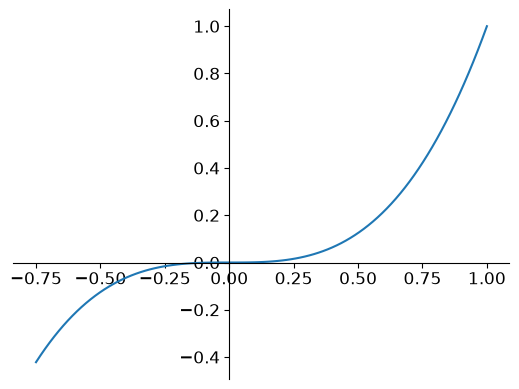

In [ ]:
fig, ax = plt.subplots()

ax.spines["right"].set_color("none")
ax.spines["top"].set_color("none")

ax.xaxis.set_ticks_position("bottom")
ax.spines["bottom"].set_position(("data", 0))  # set position of x spine to x=0

ax.yaxis.set_ticks_position("left")
ax.spines["left"].set_position(("data", 0))  # set position of y spine to y=0

xx = np.linspace(-0.75, 1.0, 100)
ax.plot(xx, xx**3)
plt.show()

### Other 2D plot styles

In addition to the regular `plot` method, there are a number of other functions for generating different kind of plots. See the matplotlib plot gallery for a complete list of available plot types: http://matplotlib.org/gallery.html. Some of the more useful ones are show below:

In [ ]:
n = np.array([0, 1, 2, 3, 4, 5])
xx = np.linspace(0, 10, 100)

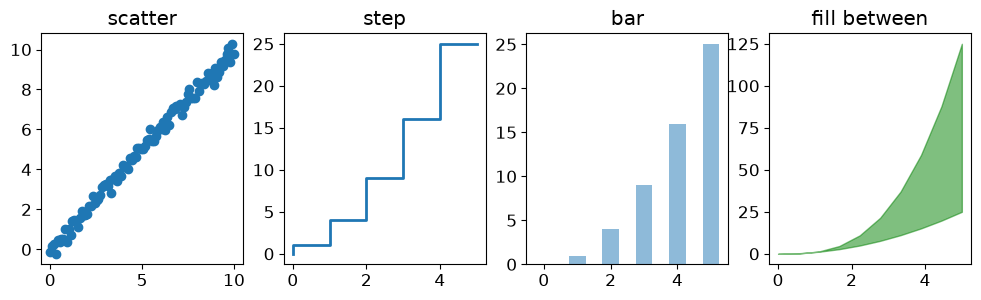

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

axes[0].scatter(xx, xx + 0.25 * np.random.randn(len(xx)))
axes[0].set_title("scatter")

axes[1].step(n, n**2, lw=2)
axes[1].set_title("step")

axes[2].bar(n, n**2, align="center", width=0.5, alpha=0.5)
axes[2].set_title("bar")

axes[3].fill_between(x, x**2, x**3, color="green", alpha=0.5)
axes[3].set_title("fill between")
plt.show()

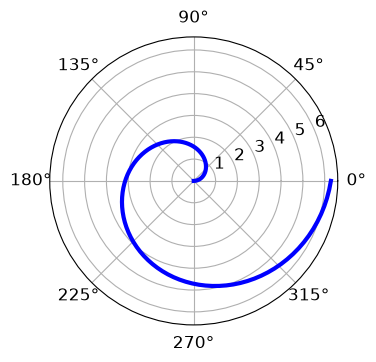

In [ ]:
# polar plot using add_axes and polar projection
fig = plt.figure()
ax = fig.add_axes([0.0, 0.0, 0.6, 0.6], polar=True)
t = np.linspace(0, 2 * np.pi, 100)
ax.plot(t, t, color="blue", lw=3)
plt.show()

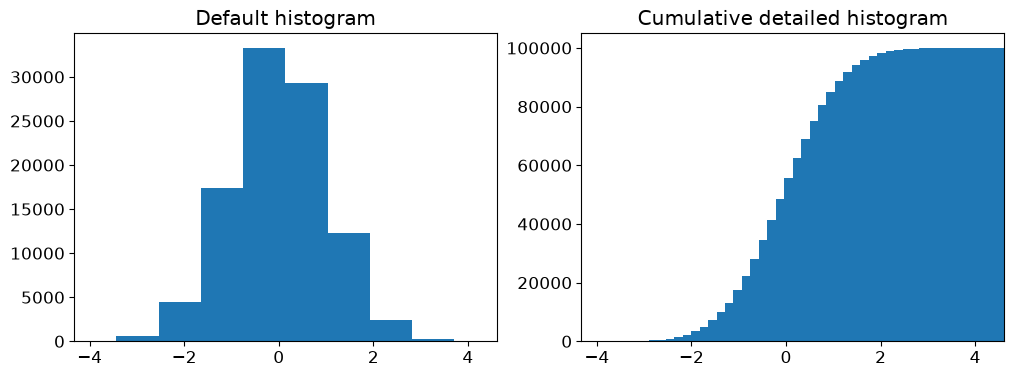

In [ ]:
# A histogram
n = np.random.randn(100000)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(n)
axes[0].set_title("Default histogram")
axes[0].set_xlim((min(n), max(n)))

axes[1].hist(n, cumulative=True, bins=50)
axes[1].set_title("Cumulative detailed histogram")
axes[1].set_xlim((min(n), max(n)))
plt.show()

### Text annotation

Annotating text in matplotlib figures can be done using the `text` function. It supports LaTeX formatting just like axis label texts and titles:

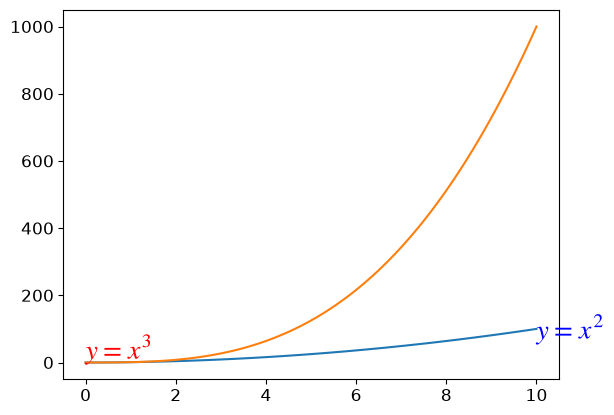

In [ ]:
fig, ax = plt.subplots()

ax.plot(xx, xx**2, xx, xx**3)

ax.text(10, 70, r"$y=x^2$", fontsize=20, color="blue")
ax.text(0.0, 10.0, r"$y=x^3$", fontsize=20, color="red")
plt.show()

### Figures with multiple subplots and insets

Axes can be added to a matplotlib Figure canvas manually using `fig.add_axes` or using a sub-figure layout manager such as `subplots`, `subplot2grid`, or `gridspec`:

#### subplots

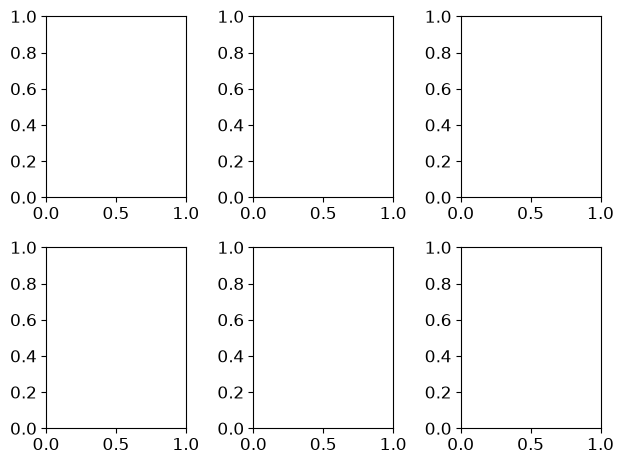

In [ ]:
fig, ax = plt.subplots(2, 3)
fig.tight_layout()
plt.show()

#### subplot2grid

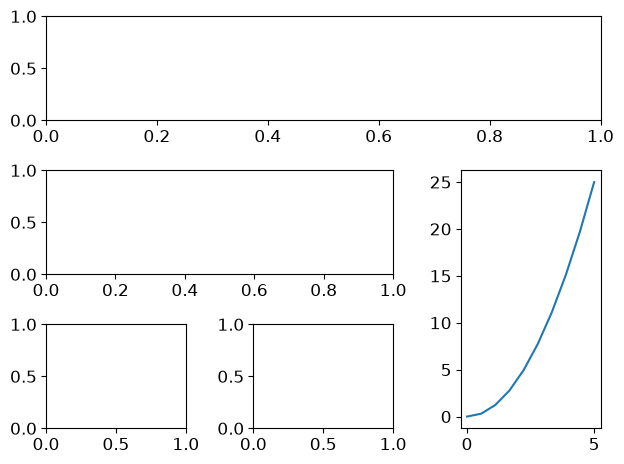

In [ ]:
fig = plt.figure()
ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=3)
ax2 = plt.subplot2grid((3, 3), (1, 0), colspan=2)
ax3 = plt.subplot2grid((3, 3), (1, 2), rowspan=2)
ax4 = plt.subplot2grid((3, 3), (2, 0))
ax5 = plt.subplot2grid((3, 3), (2, 1))
fig.tight_layout()
ax3.plot(x, x**2)
plt.show()

#### gridspec

In [ ]:
import matplotlib.gridspec as gridspec

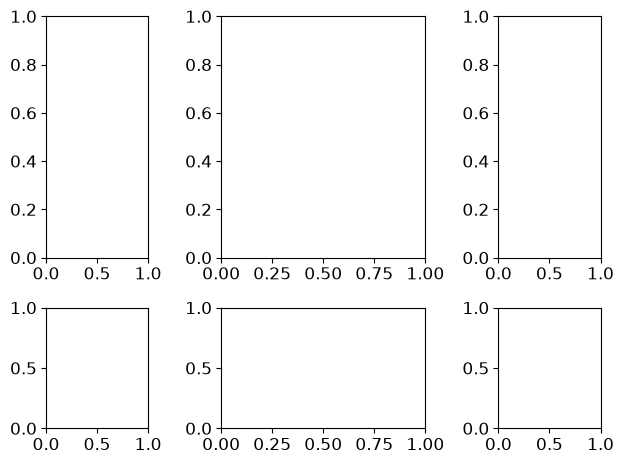

In [ ]:
fig = plt.figure()

gs = gridspec.GridSpec(2, 3, height_ratios=[2, 1], width_ratios=[1, 2, 1])
for g in gs:
    ax = fig.add_subplot(g)

fig.tight_layout()
plt.show()

#### add_axes

Manually adding axes with `add_axes` is useful for adding insets to figures:

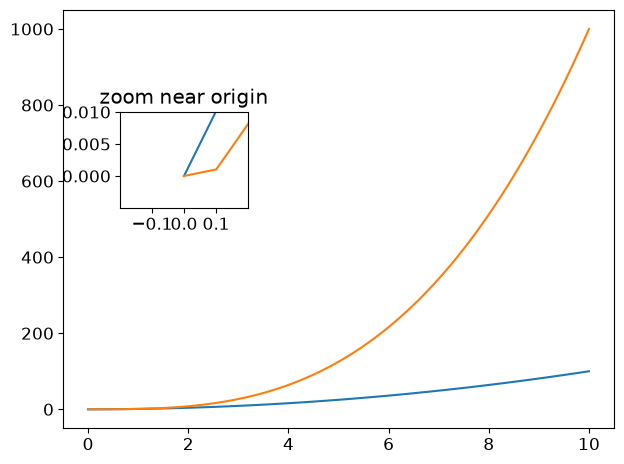

In [ ]:
fig, ax = plt.subplots()

ax.plot(xx, xx**2, xx, xx**3)
fig.tight_layout()

# inset
inset_ax = fig.add_axes([0.2, 0.55, 0.2, 0.2])  # X, Y, width, height

inset_ax.plot(xx, xx**2, xx, xx**3)
inset_ax.set_title("zoom near origin")

# set axis range
inset_ax.set_xlim(-0.2, 0.2)
inset_ax.set_ylim(-0.005, 0.01)

# set axis tick locations
inset_ax.set_yticks([0, 0.005, 0.01])
inset_ax.set_xticks([-0.1, 0, 0.1])
plt.show()

### Colormap and contour figures

Colormaps and contour figures are useful for plotting functions of two variables. In most of these functions we will use a colormap to encode one dimension of the data. There are a number of predefined colormaps. It is relatively straightforward to define custom colormaps. For a list of pre-defined colormaps, see: http://www.scipy.org/Cookbook/Matplotlib/Show_colormaps

In [ ]:
import numpy as np

alpha = 0.7
phi_ext = 2 * np.pi * 0.5


def flux_qubit_potential(phi_m, phi_p):
    return (
        2
        + alpha
        - 2 * np.cos(phi_p) * np.cos(phi_m)
        - alpha * np.cos(phi_ext - 2 * phi_p)
    )

In [ ]:
phi_m = np.linspace(0, 2 * np.pi, 100)
phi_p = np.linspace(0, 2 * np.pi, 100)
X, Y = np.meshgrid(phi_p, phi_m)
Z = flux_qubit_potential(X, Y).T

#### pcolor

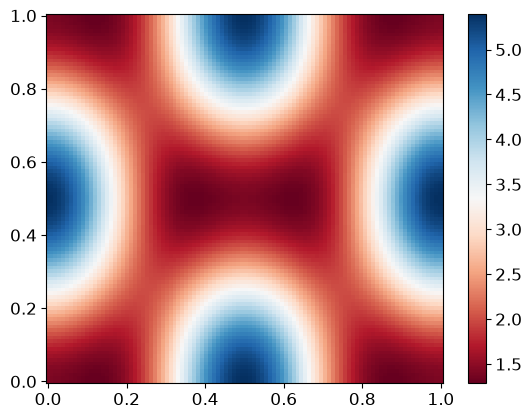

In [ ]:
fig, ax = plt.subplots()

p = ax.pcolor(
    X / (2 * np.pi),
    Y / (2 * np.pi),
    Z,
    cmap=matplotlib.cm.RdBu,
    vmin=abs(Z).min(),
    vmax=abs(Z).max(),
)
cb = fig.colorbar(p, ax=ax)
plt.show()

#### imshow

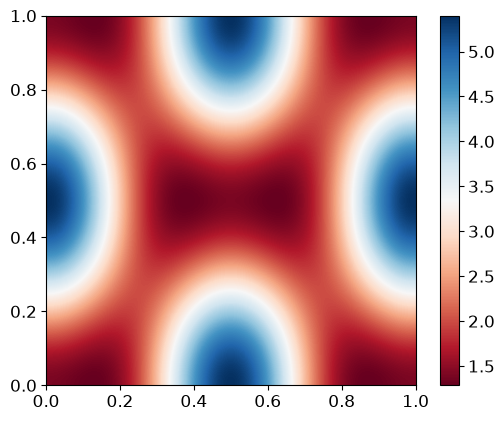

In [ ]:
fig, ax = plt.subplots()

im = ax.imshow(
    Z,
    cmap=matplotlib.cm.RdBu,
    vmin=abs(Z).min(),
    vmax=abs(Z).max(),
    extent=[0, 1, 0, 1],
)
im.set_interpolation("bilinear")

cb = fig.colorbar(im, ax=ax)
plt.show()

#### contour

In [ ]:
help(plt.contour)

Help on function contour in module matplotlib.pyplot:

contour(*args, data: DataParamType = None, **kwargs) -> QuadContourSet
    Plot contour lines.

    Call signature::

        contour([X, Y,] Z, /, [levels], **kwargs)

    The arguments *X*, *Y*, *Z* are positional-only.

    `.contour` and `.contourf` draw contour lines and filled contours,
    respectively.  Except as noted, function signatures and return values
    are the same for both versions.

    Parameters
    ----------
    X, Y : array-like, optional
        The coordinates of the values in *Z*.

        *X* and *Y* must both be 2D with the same shape as *Z* (e.g.
        created via `numpy.meshgrid`), or they must both be 1-D such
        that ``len(X) == N`` is the number of columns in *Z* and
        ``len(Y) == M`` is the number of rows in *Z*.

        *X* and *Y* must both be ordered monotonically.

        If not given, they are assumed to be integer indices, i.e.
        ``X = range(N)``, ``Y = range(M)``.

    

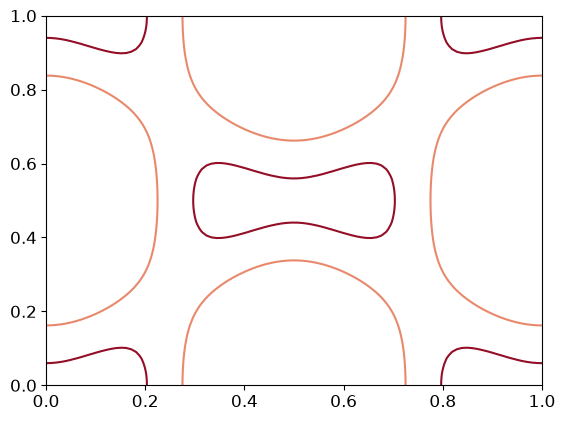

In [ ]:
fig, ax = plt.subplots()

cnt = ax.contour(
    Z,
    levels=[1.54, 2.35],
    cmap=matplotlib.cm.RdBu,
    vmin=abs(Z).min(),
    vmax=abs(Z).max(),
    extent=[0, 1, 0, 1],
)
plt.show()

## 3D figures

To use 3D graphics in matplotlib, we first need to create an instance of the `Axes3D` class. 3D axes can be added to a matplotlib figure canvas in exactly the same way as 2D axes; or, more conveniently, by passing a `projection='3d'` keyword argument to the `add_axes` or `add_subplot` methods.

In [ ]:
from mpl_toolkits.mplot3d.axes3d import Axes3D

#### Surface plots

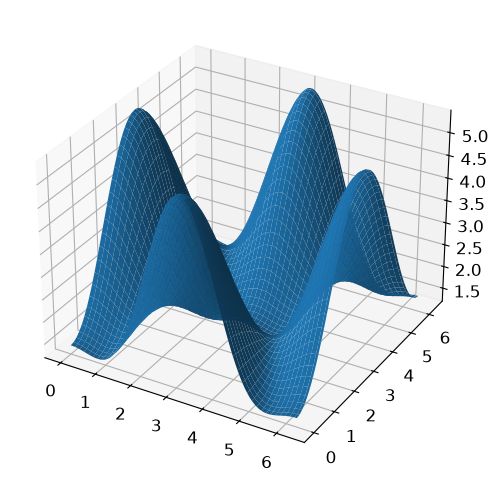

In [ ]:
fig = plt.figure(figsize=(14, 6))
from matplotlib import cm

# `ax` is a 3D-aware axis instance because of the projection='3d' keyword argument to add_subplot
ax = fig.add_subplot(1, 2, 1, projection="3d")

p = ax.plot_surface(X, Y, Z, linewidth=0.2)
plt.show()

#### Wire-frame plot

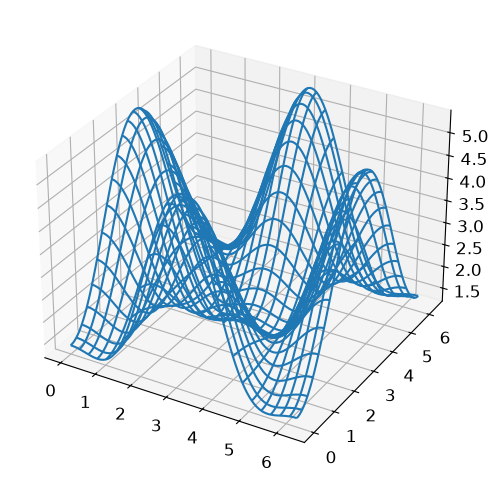

In [ ]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(1, 1, 1, projection="3d")

p = ax.plot_wireframe(X, Y, Z, rstride=4, cstride=4)
plt.show()

#### Coutour plots with projections

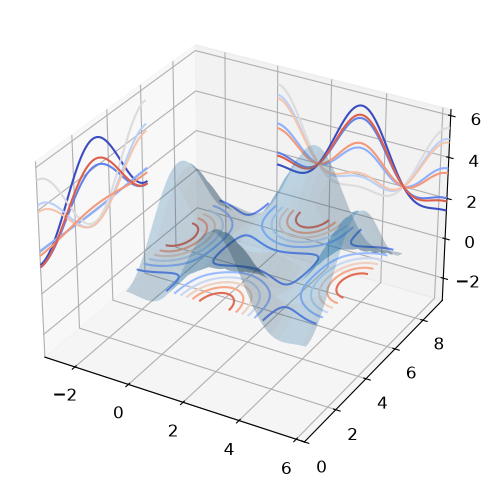

In [ ]:
# %matplotlib notebook
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(1, 1, 1, projection="3d")

ax.plot_surface(X, Y, Z, rstride=20, cstride=4, alpha=0.25)
cset = ax.contour(X, Y, Z, zdir="z", offset=2, cmap=matplotlib.cm.coolwarm)
cset = ax.contour(X, Y, Z, zdir="x", offset=-np.pi, cmap=matplotlib.cm.coolwarm)
cset = ax.contour(X, Y, Z, zdir="y", offset=3 * np.pi, cmap=matplotlib.cm.coolwarm)

ax.set_xlim3d(-np.pi, 2 * np.pi)
ax.set_ylim3d(0, 3 * np.pi)
ax.set_zlim3d(-np.pi, 2 * np.pi)
plt.show()

#### Change the view angle

We can change the perspective of a 3D plot using the `view_init` method, which takes two arguments: `elevation` and `azimuth` angle (in degrees):

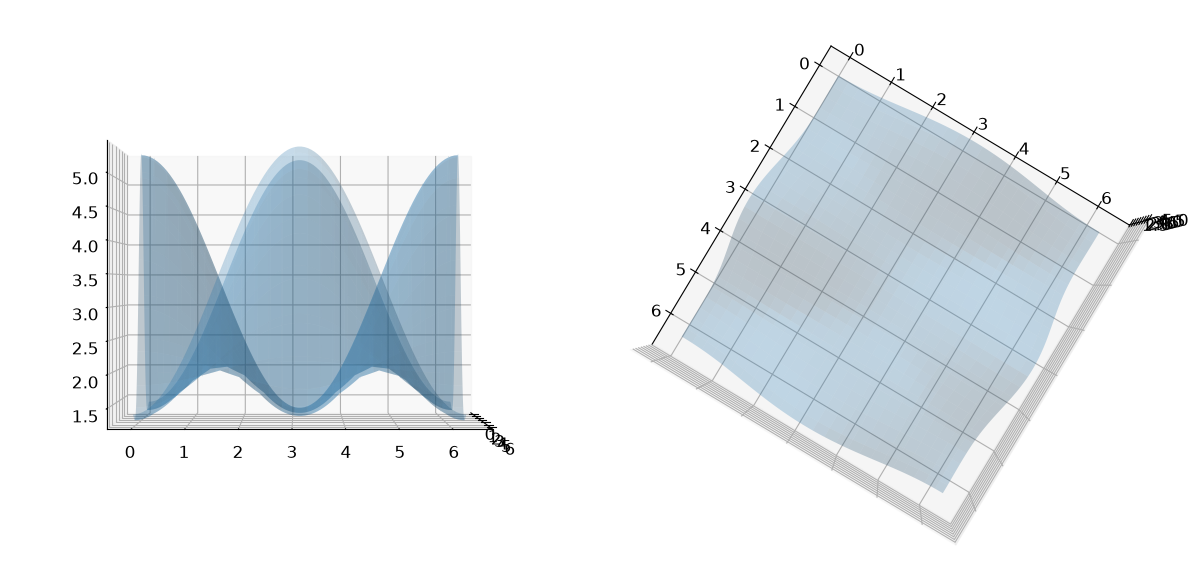

In [ ]:
%matplotlib inline
fig = plt.figure(figsize=(12, 6))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, alpha=0.25)
ax.view_init(0, 0)

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.plot_surface(X, Y, Z, rstride=4, cstride=4, alpha=0.25)
ax.view_init(90, 30)

fig.tight_layout()
plt.show()

### Quiver plot

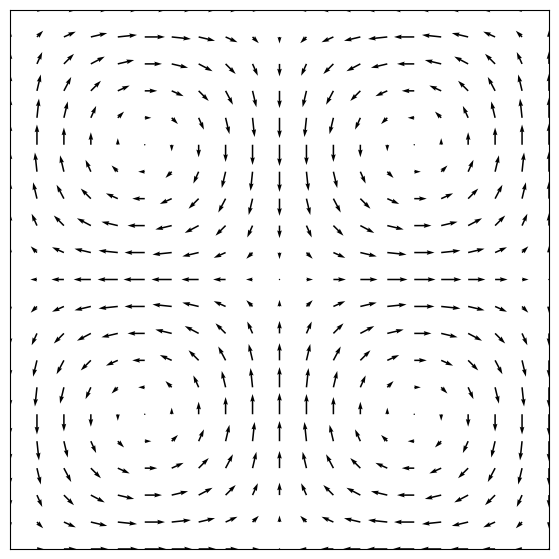

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 2 * np.pi + 2 * np.pi / 20, 2 * np.pi / 20)
y = np.arange(0, 2 * np.pi + 2 * np.pi / 20, 2 * np.pi / 20)

X, Y = np.meshgrid(x, y)

u = np.sin(X) * np.cos(Y)
v = -np.cos(X) * np.sin(Y)

fig, ax = plt.subplots(figsize=(7, 7))

ax.quiver(X, Y, u, v)

ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])
ax.axis([0, 2 * np.pi, 0, 2 * np.pi])
ax.set_aspect("equal")

plt.show()

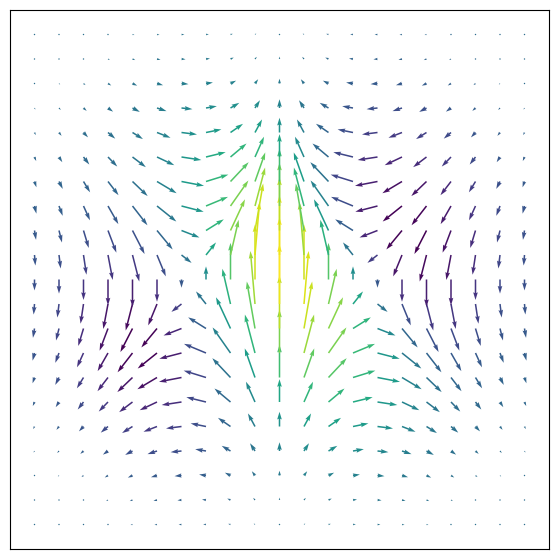

In [ ]:
x = np.arange(-2, 2.2, 0.2)
y = np.arange(-2, 2.2, 0.2)


X, Y = np.meshgrid(x, y)
z = X * np.exp(-(X**2) - Y**2)
dx, dy = np.gradient(z)

n = -2
color_array = np.sqrt(((dx - n) / 2) ** 2 + ((dy - n) / 2) ** 2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.quiver(X, Y, dx, dy, color_array)

ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])
ax.set_aspect("equal")

plt.show()